## Задание 1


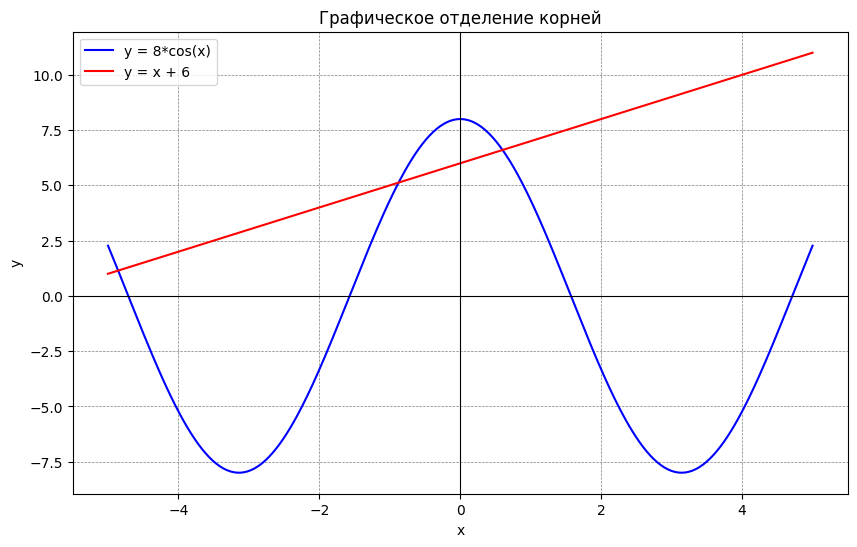

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Задаем интервал для оси X
x = np.linspace(-5, 5, 400)

# Две функции для левой и правой части уравнения
y1 = 8 * np.cos(x)
y2 = x + 6

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='y = 8*cos(x)', color='blue')
plt.plot(x, y2, label='y = x + 6', color='red')

# Оформление графика
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.title('Графическое отделение корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Показываем график
plt.show()

# Вывод: На графике можно увидеть, что графики пересекаются 
# в точке, находящейся на отрезке [0, 1]. Будем искать корень там.

## Задание 2


In [2]:
import math
import pandas as pd

def f(x):
    return 8 * math.cos(x) - x - 6

# Параметры
a = 0.0
b = 1.0
tolerance = 1e-3

print("Задание 2: Метод половинного деления")

# Список для хранения данных
data = []

iteration = 0
while (b - a) / 2 > tolerance:
    iteration += 1
    c = (a + b) / 2
    fc = f(c)
    
    # Добавляем данные в список
    data.append({
        'Итерация': iteration,
        'a': round(a, 6),
        'b': round(b, 6),
        'c': round(c, 6),
        'f(c)': round(fc, 6),
        '|b-a|/2': round((b - a) / 2, 6)
    })
    
    if fc == 0:
        break  # Найден точный корень
    elif f(a) * fc < 0:
        b = c  # Корень в левой половине
    else:
        a = c  # Корень в правой половине

# Создаем DataFrame и выводим таблицу
df = pd.DataFrame(data)
print(df.to_string(index=False))

root = (a + b) / 2
print("-" * 70)
print(f"Приближенный корень: {root:.4f}")
print(f"Достигнутая точность: {(b-a)/2:.6f}")

Задание 2: Метод половинного деления
 Итерация        a        b        c      f(c)  |b-a|/2
        1 0.000000 1.000000 0.500000  0.520660 0.500000
        2 0.500000 1.000000 0.750000 -0.896489 0.250000
        3 0.500000 0.750000 0.625000 -0.137295 0.125000
        4 0.500000 0.625000 0.562500  0.204896 0.062500
        5 0.562500 0.625000 0.593750  0.037038 0.031250
        6 0.593750 0.625000 0.609375 -0.049328 0.015625
        7 0.593750 0.609375 0.601562 -0.005944 0.007812
        8 0.593750 0.601562 0.597656  0.015598 0.003906
        9 0.597656 0.601562 0.599609  0.004840 0.001953
----------------------------------------------------------------------
Приближенный корень: 0.6006
Достигнутая точность: 0.000977


## Задание 3

In [3]:
import math

def phi(x):
    return math.acos((x + 6) / 8)

x_prev = 0.5 # Начальное приближение из отрезка [0, 1]
tolerance = 1e-6
iteration = 0

print("Задание 3: Метод простой итерации")

while True:
    iteration += 1
    x_curr = phi(x_prev)
    diff = abs(x_curr - x_prev)
    
    if diff < tolerance:
        break
        
    x_prev = x_curr

print(f"Найденный корень: {x_curr:.6f}")
print(f"Количество итераций: {iteration}")

Задание 3: Метод простой итерации
Найденный корень: 0.600487
Количество итераций: 9


## Задание 4


In [4]:
import math

def f(x):
    return 8 * math.cos(x) - x - 6

def df(x): # Первая производная
    return -8 * math.sin(x) - 1

def d2f(x): # Вторая производная
    return -8 * math.cos(x)

a = 0.0
b = 1.0
tolerance = 1e-6
iteration = 0

print("Задание 4: Комбинированный метод хорд и касательных")

while abs(b - a) > tolerance:
    iteration += 1
    
    a_next = a - f(a) * (b - a) / (f(b) - f(a)) # Метод хорд
    b_next = b - f(b) / df(b)                   # Метод касательных
    
    a = a_next
    b = b_next

root = (a + b) / 2
print(f"Найденный корень: {root:.6f}")
print(f"Количество итераций: {iteration}")

Задание 4: Комбинированный метод хорд и касательных
Найденный корень: 0.600487
Количество итераций: 4


## Задание 5

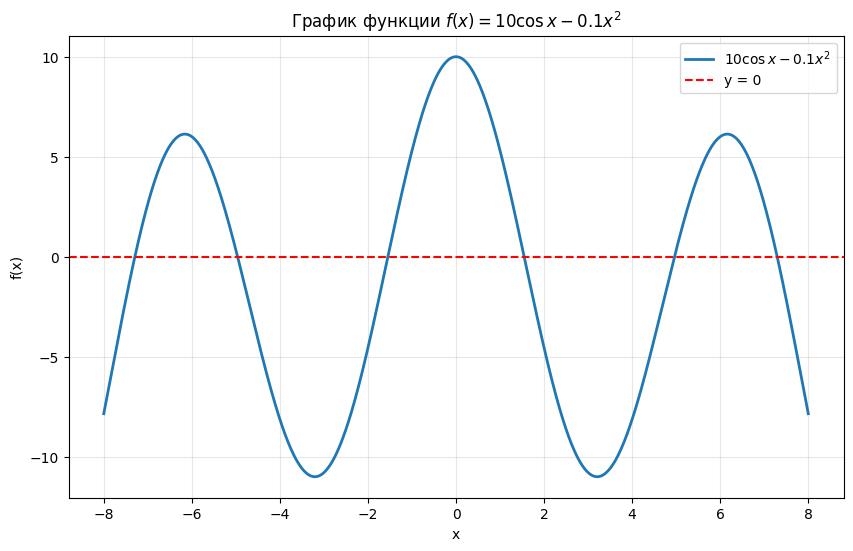

Найденные корни (с точностью 10^-6):
Корень 1: x = -4.96106339, f(x) = -2.14e-05
Корень 2: x = -1.54686642, f(x) = -3.31e-06
Корень 3: x = 1.54686642, f(x) = -3.31e-06
Корень 4: x = 4.96106339, f(x) = -2.14e-05


In [2]:
import numpy as np
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

# Определение функции
def f(x):
    return 10 * np.cos(x) - 0.1 * x**2

# Построение графика для локализации корней
x_vals = np.linspace(-8, 8, 1000)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, linewidth=2, label='$10 \\cos x - 0.1x^2$')
plt.axhline(0, color='red', linestyle='--', label='y = 0')
plt.grid(True, alpha=0.3)
plt.title('График функции $f(x) = 10 \\cos x - 0.1x^2$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

# Поиск корней на разных интервалах
intervals = [(-5, -3), (-3, -1), (1, 3), (3, 5)]  # интервалы, где функция меняет знак

roots = []
for a, b in intervals:
    if f(a) * f(b) < 0:
        sol = root_scalar(f, bracket=[a, b], method='bisect', rtol=1e-6)
        roots.append(sol.root)

print("Найденные корни (с точностью 10^-6):")
for i, root in enumerate(roots):
    print(f"Корень {i+1}: x = {root:.8f}, f(x) = {f(root):.2e}")

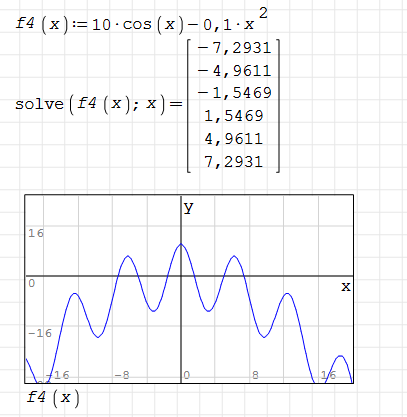

Использование встроенных средств Python (scipy.optimize.root_scalar) позволяет быстро и точно найти все корни уравнения. Благодаря симметрии уравнения, достаточно найти положительные корни, а отрицательные получить автоматически.

Точность 10^-6 легко достигается методом бисекции, который гарантированно сходится на интервалах, где функция меняет знак.